# PINN Concepts — Visual Guide for HW Engineers

**AI가 처음인 HW 엔지니어를 위한 시각적 가이드**

이 노트북은 우리 프로젝트에서 사용하는 모든 AI 개념을 **직접 돌려보면서** 이해할 수 있도록 구성했습니다.

---

## 목차

| # | 주제 | 핵심 질문 |
|---|------|----------|
| 1 | Neural Network 기초 | 신경망이 뭘 하는 거야? |
| 2 | PINN이란? | 물리를 어떻게 학습해? |
| 3 | Basic PINN vs Parametric PINN | 왜 Parametric이어야 역설계 가능? |
| 4 | Helmholtz 방정식 | 우리가 풀려는 물리가 뭐야? |
| 5 | 4개 Loss의 역할 | 각 Loss가 뭘 가르쳐? |
| 6 | Collocation Points | 학습 데이터가 어디서 와? |
| 7 | 학습 과정 라이브 데모 | 실제로 학습이 어떻게 진행돼? |
| 8 | 학습 결과 해석법 | 결과를 어떻게 읽어야 해? |

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise FileNotFoundError('Cannot find project root')

PROJECT_ROOT = _find_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)
print('Ready!')

Ready!


---
# 1. Neural Network 기초

## 신경망 = "만능 함수 근사기"

- 입력(x)을 넣으면 출력(y)을 내는 **함수**입니다
- 내부에 조절 가능한 **파라미터(weights)** 가 있어서, 데이터를 보고 스스로 조절합니다
- 이 조절 과정을 **학습(training)** 이라고 합니다

### HW 비유
```
Op-Amp 회로        vs     Neural Network
─────────────             ─────────────
R, C 값 조정              weight 값 조정
전달함수 결정              함수 형태 결정
입력 신호 → 출력 신호      입력 데이터 → 출력 데이터
설계자가 R,C 결정          학습이 weight 결정 (자동!)
```

### 직접 보기: 간단한 함수 학습

파라미터 수: 1,153개
(Op-Amp로 치면 R, C 값이 1153개 있는 셈)


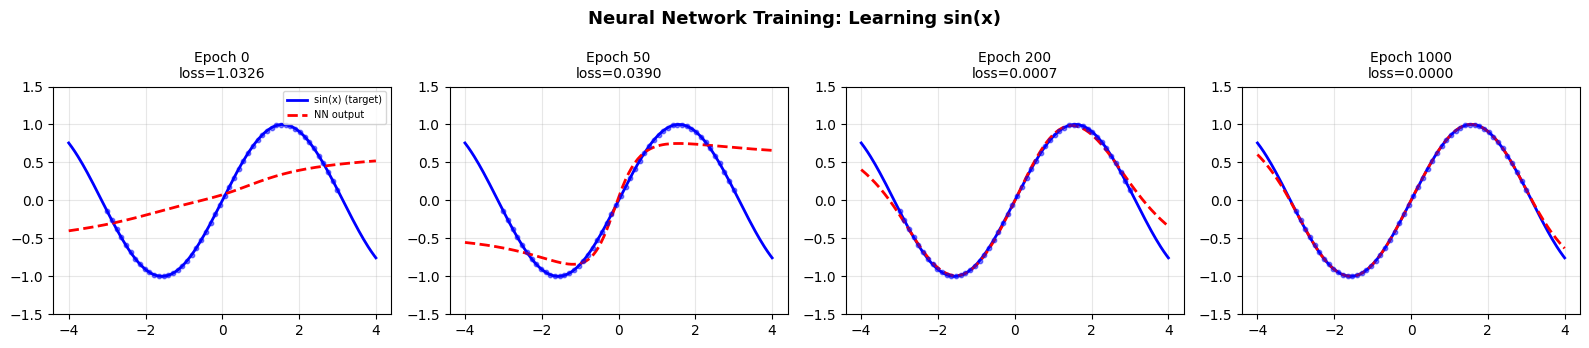


→ 빨간 점선(NN)이 파란 실선(sin)에 점점 가까워지는 것이 "학습"입니다!
→ loss 숫자가 줄어듦 = 점점 잘 배우고 있음


In [2]:
# ── 신경망이 sin(x) 함수를 배우는 과정 ──

# 1. 아주 간단한 신경망 (입력 1개 → 출력 1개)
simple_net = nn.Sequential(
    nn.Linear(1, 32),   # 입력 1차원 → 32개 뉴런
    nn.Tanh(),           # 비선형 활성화 (곡선을 만들 수 있게)
    nn.Linear(32, 32),  # 32 → 32
    nn.Tanh(),
    nn.Linear(32, 1),   # 32 → 출력 1차원
)
print(f'파라미터 수: {sum(p.numel() for p in simple_net.parameters()):,}개')
print(f'(Op-Amp로 치면 R, C 값이 {sum(p.numel() for p in simple_net.parameters())}개 있는 셈)')

# 2. 학습 데이터: sin(x)
x_train = torch.linspace(-3, 3, 50).unsqueeze(1)  # 50개 점
y_target = torch.sin(x_train)                       # 정답

# 3. 학습 과정 시각화
optimizer = torch.optim.Adam(simple_net.parameters(), lr=0.01)
x_test = torch.linspace(-4, 4, 200).unsqueeze(1)  # 시각화용 (더 넓은 범위)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
snapshots = [0, 50, 200, 1000]
snap_idx = 0

for epoch in range(1001):
    y_pred = simple_net(x_train)
    loss = ((y_pred - y_target)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if snap_idx < len(snapshots) and epoch == snapshots[snap_idx]:
        ax = axes[snap_idx]
        with torch.no_grad():
            y_test = simple_net(x_test)
        ax.plot(x_test.numpy(), np.sin(x_test.numpy()), 'b-', lw=2, label='sin(x) (target)')
        ax.plot(x_test.numpy(), y_test.numpy(), 'r--', lw=2, label='NN output')
        ax.scatter(x_train.numpy(), y_target.numpy(), c='blue', s=10, alpha=0.5, zorder=5)
        ax.set_title(f'Epoch {epoch}\nloss={loss.item():.4f}', fontsize=10)
        ax.set_ylim(-1.5, 1.5)
        ax.grid(True, alpha=0.3)
        if epoch == 0: ax.legend(fontsize=7)
        snap_idx += 1

fig.suptitle('Neural Network Training: Learning sin(x)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n→ 빨간 점선(NN)이 파란 실선(sin)에 점점 가까워지는 것이 "학습"입니다!')
print('→ loss 숫자가 줄어듦 = 점점 잘 배우고 있음')

---
# 2. PINN이란?

## Physics-Informed Neural Network = 물리를 아는 신경망

### 일반 NN vs PINN

```
일반 Neural Network:                PINN:
───────────────────                 ─────
데이터만으로 학습                    데이터 + 물리법칙으로 학습
대량 데이터 필요 (수만~수십만)       소량 데이터 OK (물리가 보충)
물리적으로 말이 안 되는 결과 가능    물리법칙 만족 보장

예시: 온도 예측                      예시: 온도 예측
- 센서 100만개 → 학습               - 센서 10개 + 열전도 방정식 → 학습
- 벽 온도가 1000°C? OK (데이터면)    - 벽 온도가 1000°C? 열방정식 위반!
```

### 우리 프로젝트에서:
- **물리법칙**: Helmholtz 방정식 (∇²U + k²U = 0)
- **데이터**: ASM 전파 결과 (z=40 경계), BM 경계조건
- **PINN이 학습하는 것**: BM을 통과하는 빛의 회절 패턴

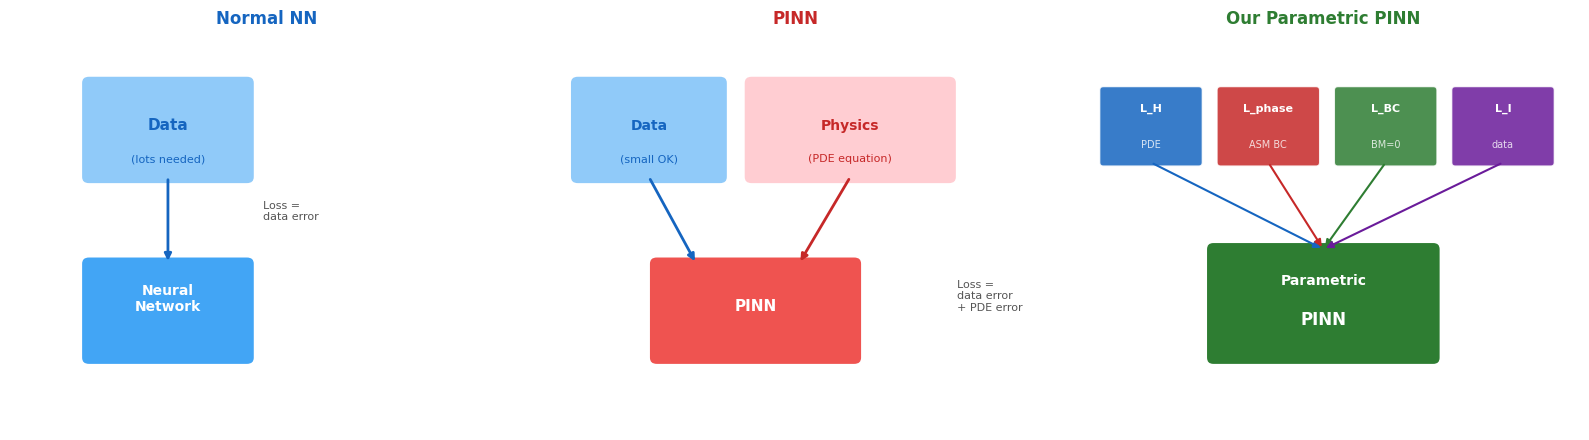

In [3]:
# ── PINN의 핵심 아이디어 시각화 ──

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) 일반 NN: 데이터로만 학습
ax = axes[0]
ax.set_xlim(-0.5, 6)
ax.set_ylim(-0.5, 5)
ax.axis('off')
ax.set_title('Normal NN', fontsize=12, fontweight='bold', color='#1565C0')

ax.add_patch(FancyBboxPatch((0.5, 3), 2, 1.3, boxstyle='round,pad=0.1',
             facecolor='#90CAF9', edgecolor='white', lw=1.5))
ax.text(1.5, 3.65, 'Data', ha='center', fontsize=11, fontweight='bold', color='#1565C0')
ax.text(1.5, 3.2, '(lots needed)', ha='center', fontsize=8, color='#1565C0')

ax.add_patch(FancyBboxPatch((0.5, 0.5), 2, 1.3, boxstyle='round,pad=0.1',
             facecolor='#42A5F5', edgecolor='white', lw=1.5))
ax.text(1.5, 1.15, 'Neural\nNetwork', ha='center', fontsize=10, fontweight='bold', color='white')

ax.annotate('', xy=(1.5, 1.8), xytext=(1.5, 3), arrowprops=dict(arrowstyle='-|>', color='#1565C0', lw=2))
ax.text(2.7, 2.4, 'Loss =\ndata error', fontsize=8, color='#555')

# (b) PINN: 데이터 + 물리
ax = axes[1]
ax.set_xlim(-0.5, 6)
ax.set_ylim(-0.5, 5)
ax.axis('off')
ax.set_title('PINN', fontsize=12, fontweight='bold', color='#C62828')

ax.add_patch(FancyBboxPatch((0, 3), 1.8, 1.3, boxstyle='round,pad=0.1',
             facecolor='#90CAF9', edgecolor='white', lw=1.5))
ax.text(0.9, 3.65, 'Data', ha='center', fontsize=10, fontweight='bold', color='#1565C0')
ax.text(0.9, 3.2, '(small OK)', ha='center', fontsize=8, color='#1565C0')

ax.add_patch(FancyBboxPatch((2.2, 3), 2.5, 1.3, boxstyle='round,pad=0.1',
             facecolor='#FFCDD2', edgecolor='white', lw=1.5))
ax.text(3.45, 3.65, 'Physics', ha='center', fontsize=10, fontweight='bold', color='#C62828')
ax.text(3.45, 3.2, '(PDE equation)', ha='center', fontsize=8, color='#C62828')

ax.add_patch(FancyBboxPatch((1, 0.5), 2.5, 1.3, boxstyle='round,pad=0.1',
             facecolor='#EF5350', edgecolor='white', lw=1.5))
ax.text(2.25, 1.15, 'PINN', ha='center', fontsize=11, fontweight='bold', color='white')

ax.annotate('', xy=(1.5, 1.8), xytext=(0.9, 3), arrowprops=dict(arrowstyle='-|>', color='#1565C0', lw=2))
ax.annotate('', xy=(2.8, 1.8), xytext=(3.45, 3), arrowprops=dict(arrowstyle='-|>', color='#C62828', lw=2))
ax.text(4.8, 1.15, 'Loss =\ndata error\n+ PDE error', fontsize=8, color='#555')

# (c) Our PINN: 4 losses
ax = axes[2]
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 5)
ax.axis('off')
ax.set_title('Our Parametric PINN', fontsize=12, fontweight='bold', color='#2E7D32')

losses = [
    ('L_H', 'PDE', '#1565C0', 0),
    ('L_phase', 'ASM BC', '#C62828', 1.6),
    ('L_BC', 'BM=0', '#2E7D32', 3.2),
    ('L_I', 'data', '#6A1B9A', 4.8),
]
for name, desc, color, x in losses:
    ax.add_patch(FancyBboxPatch((x, 3.2), 1.3, 1, boxstyle='round,pad=0.05',
                 facecolor=color, edgecolor='white', lw=1, alpha=0.85))
    ax.text(x+0.65, 3.9, name, ha='center', fontsize=8, fontweight='bold', color='white')
    ax.text(x+0.65, 3.4, desc, ha='center', fontsize=7, color='white', alpha=0.8)
    ax.annotate('', xy=(3, 2), xytext=(x+0.65, 3.2), arrowprops=dict(arrowstyle='-|>', color=color, lw=1.5))

ax.add_patch(FancyBboxPatch((1.5, 0.5), 3, 1.5, boxstyle='round,pad=0.1',
             facecolor='#2E7D32', edgecolor='white', lw=1.5))
ax.text(3, 1.5, 'Parametric', ha='center', fontsize=10, fontweight='bold', color='white')
ax.text(3, 0.95, 'PINN', ha='center', fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

---
# 3. Basic PINN vs Parametric PINN

## 왜 Parametric이어야 역설계가 되나?

이것이 이 프로젝트의 **핵심 차이점**입니다.

C:\Users\k2kw2\AppData\Local\Temp\ipykernel_27264\86190177.py:97: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\k2kw2\AppData\Local\Temp\ipykernel_27264\86190177.py:97: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\k2kw2\AppData\Local\Temp\ipykernel_27264\86190177.py:97: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\k2kw2\AppData\Local\Temp\ipykernel_27264\86190177.py:97: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\k2kw2\AppData\Local\Temp\ipykernel_27264\86190177.py:97: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\k2kw2\AppData\Local\Temp\ipykernel_27264\86190177.py:97: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s)

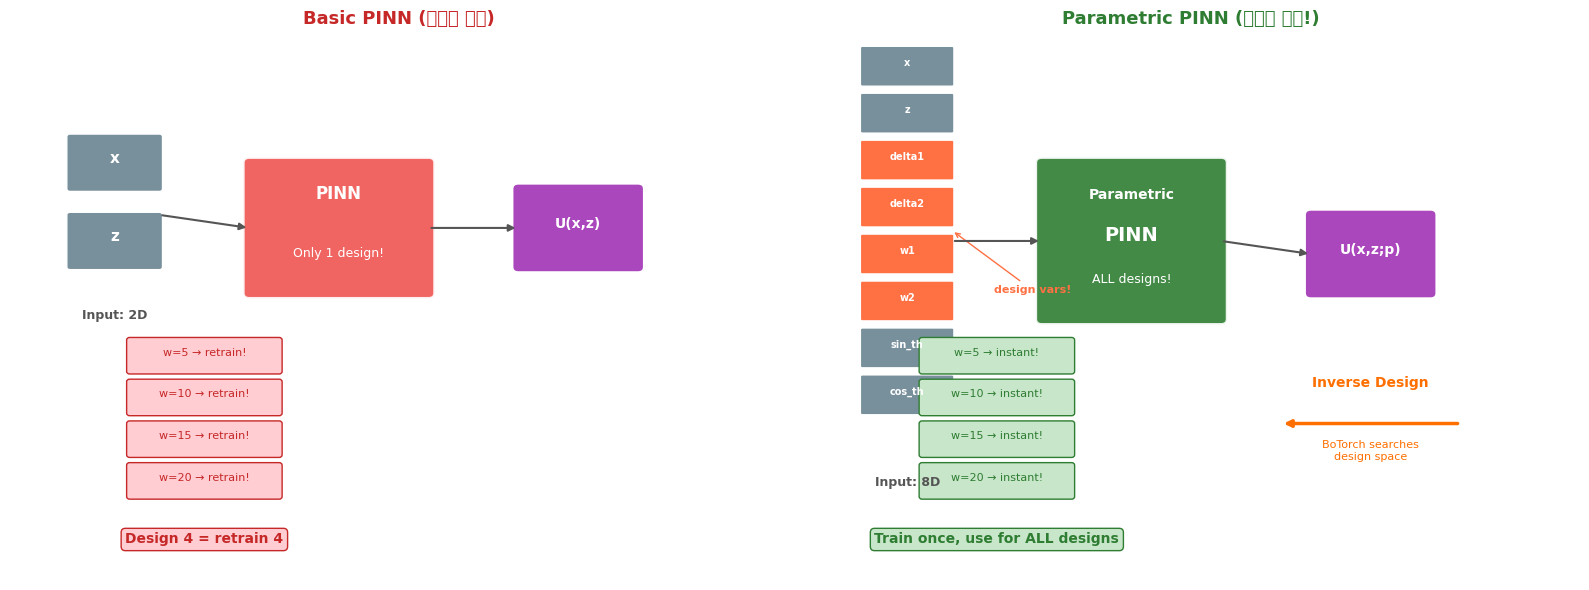

핵심: Parametric PINN은 설계변수를 입력에 포함하기 때문에
      한 번 학습하면 어떤 (delta, w) 조합이든 즉시 예측 가능!
      → BoTorch가 이 PINN을 빠르게 호출하면서 최적 설계를 찾음 = 역설계


In [4]:
# ── Basic PINN vs Parametric PINN 비교 ──

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Basic PINN ──
ax = axes[0]
ax.set_xlim(-1, 12)
ax.set_ylim(-1.5, 9)
ax.axis('off')
ax.set_title('Basic PINN (역설계 불가)', fontsize=13, fontweight='bold', color='#C62828')

# Input
for i, lbl in enumerate(['x', 'z']):
    ax.add_patch(FancyBboxPatch((0, 6-i*1.5), 1.5, 1, boxstyle='round,pad=0.05',
                 facecolor='#78909C', edgecolor='white', lw=1))
    ax.text(0.75, 6.5-i*1.5, lbl, ha='center', fontsize=11, fontweight='bold', color='white')
ax.text(0.75, 3.5, 'Input: 2D', ha='center', fontsize=9, fontweight='bold', color='#555')

# Network
ax.add_patch(FancyBboxPatch((3, 4), 3, 2.5, boxstyle='round,pad=0.1',
             facecolor='#EF5350', edgecolor='white', lw=2, alpha=0.9))
ax.text(4.5, 5.8, 'PINN', ha='center', fontsize=12, fontweight='bold', color='white')
ax.text(4.5, 4.7, 'Only 1 design!', ha='center', fontsize=9, color='white')
ax.annotate('', xy=(3, 5.25), xytext=(1.5, 5.5), arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.5))

# Output
ax.add_patch(FancyBboxPatch((7.5, 4.5), 2, 1.5, boxstyle='round,pad=0.1',
             facecolor='#AB47BC', edgecolor='white', lw=1.5))
ax.text(8.5, 5.25, 'U(x,z)', ha='center', fontsize=10, fontweight='bold', color='white')
ax.annotate('', xy=(7.5, 5.25), xytext=(6, 5.25), arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.5))

# Problem: multiple designs = multiple models
designs = ['w=5', 'w=10', 'w=15', 'w=20']
for i, d in enumerate(designs):
    y = 2.5 - i * 0.8
    ax.add_patch(FancyBboxPatch((1, y), 2.5, 0.6, boxstyle='round,pad=0.05',
                 facecolor='#FFCDD2', edgecolor='#C62828', lw=1))
    ax.text(2.25, y+0.3, f'{d} → retrain!', ha='center', fontsize=8, color='#C62828')

ax.text(2.25, -0.8, 'Design 4 = retrain 4', ha='center', fontsize=10,
        fontweight='bold', color='#C62828',
        bbox=dict(boxstyle='round', facecolor='#FFCDD2', edgecolor='#C62828'))

# ── Right: Parametric PINN ──
ax = axes[1]
ax.set_xlim(-1, 12)
ax.set_ylim(-1.5, 9)
ax.axis('off')
ax.set_title('Parametric PINN (역설계 가능!)', fontsize=13, fontweight='bold', color='#2E7D32')

# Input
input_labels = ['x', 'z', 'delta1', 'delta2', 'w1', 'w2', 'sin_th', 'cos_th']
input_colors = ['#78909C','#78909C','#FF7043','#FF7043','#FF7043','#FF7043','#78909C','#78909C']
for i, (lbl, clr) in enumerate(zip(input_labels, input_colors)):
    ax.add_patch(FancyBboxPatch((0, 8-i*0.9), 1.5, 0.7, boxstyle='round,pad=0.03',
                 facecolor=clr, edgecolor='white', lw=0.8))
    ax.text(0.75, 8.35-i*0.9, lbl, ha='center', fontsize=7, fontweight='bold', color='white')

ax.text(0.75, 0.3, 'Input: 8D', ha='center', fontsize=9, fontweight='bold', color='#555')
ax.annotate('design vars!', xy=(1.5, 5.2), xytext=(2.2, 4),
            fontsize=8, fontweight='bold', color='#FF7043',
            arrowprops=dict(arrowstyle='->', color='#FF7043'))

# Network
ax.add_patch(FancyBboxPatch((3, 3.5), 3, 3, boxstyle='round,pad=0.1',
             facecolor='#2E7D32', edgecolor='white', lw=2, alpha=0.9))
ax.text(4.5, 5.8, 'Parametric', ha='center', fontsize=10, fontweight='bold', color='white')
ax.text(4.5, 5.0, 'PINN', ha='center', fontsize=14, fontweight='bold', color='white')
ax.text(4.5, 4.2, 'ALL designs!', ha='center', fontsize=9, color='white')
ax.annotate('', xy=(3, 5), xytext=(1.5, 5), arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.5))

# Output
ax.add_patch(FancyBboxPatch((7.5, 4), 2, 1.5, boxstyle='round,pad=0.1',
             facecolor='#AB47BC', edgecolor='white', lw=1.5))
ax.text(8.5, 4.75, 'U(x,z;p)', ha='center', fontsize=10, fontweight='bold', color='white')
ax.annotate('', xy=(7.5, 4.75), xytext=(6, 5), arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.5))

# Advantage: any design instantly
designs = ['w=5', 'w=10', 'w=15', 'w=20']
for i, d in enumerate(designs):
    y = 2.5 - i * 0.8
    ax.add_patch(FancyBboxPatch((1, y), 2.5, 0.6, boxstyle='round,pad=0.05',
                 facecolor='#C8E6C9', edgecolor='#2E7D32', lw=1))
    ax.text(2.25, y+0.3, f'{d} → instant!', ha='center', fontsize=8, color='#2E7D32')

ax.text(2.25, -0.8, 'Train once, use for ALL designs', ha='center', fontsize=10,
        fontweight='bold', color='#2E7D32',
        bbox=dict(boxstyle='round', facecolor='#C8E6C9', edgecolor='#2E7D32'))

# Inverse design arrow
ax.annotate('', xy=(7, 1.5), xytext=(10, 1.5),
            arrowprops=dict(arrowstyle='-|>', color='#FF6F00', lw=2.5))
ax.text(8.5, 2.2, 'Inverse Design', ha='center', fontsize=10,
        fontweight='bold', color='#FF6F00')
ax.text(8.5, 0.8, 'BoTorch searches\ndesign space', ha='center', fontsize=8, color='#FF6F00')

plt.tight_layout()
plt.show()

print('핵심: Parametric PINN은 설계변수를 입력에 포함하기 때문에')
print('      한 번 학습하면 어떤 (delta, w) 조합이든 즉시 예측 가능!')
print('      → BoTorch가 이 PINN을 빠르게 호출하면서 최적 설계를 찾음 = 역설계')

---
# 4. Helmholtz Equation

## 우리가 PINN에게 가르치는 물리법칙

### Scalar Helmholtz Equation:
$$\nabla^2 U + k^2 U = 0$$

$$\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial z^2} + k^2 U = 0$$

### HW 비유
```
이 방정식은 "빛이 매질 속에서 어떻게 퍼져나가는지"를 기술합니다.

전자기학의 Maxwell 방정식 → 단순화 → Helmholtz

k = 2π·n/λ = 2π·1.52/0.520 ≈ 18.37 μm⁻¹
  n = 1.52 (Cover Glass 굴절률)
  λ = 520 nm (녹색광)
```

### PINN에서의 의미
- PINN은 U(x,z)를 예측하는 신경망
- U를 x, z로 미분하면 ∂²U/∂x², ∂²U/∂z²를 구할 수 있음 (autograd)
- 이 미분값들이 Helmholtz를 만족하는지 체크 → **L_H loss**

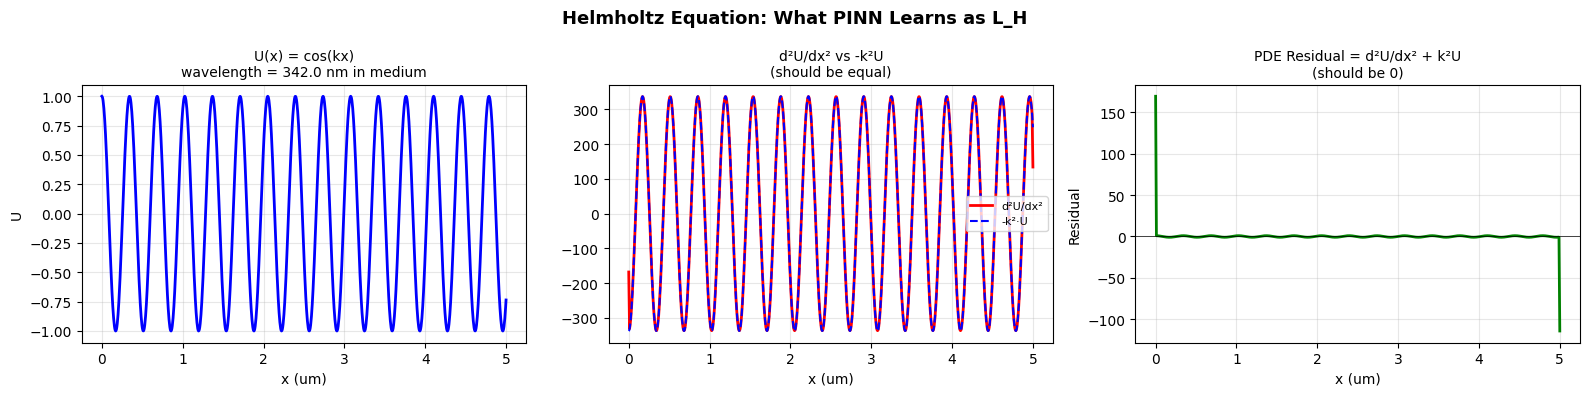

k = 18.37 um^-1
medium wavelength = 342.0 nm (0.3420 um)
PDE residual (should be ~0): mean = 1.0355

→ PINN의 L_H loss는 이 PDE residual을 0으로 만들도록 학습합니다
→ 즉, PINN이 물리적으로 올바른 파동 패턴을 출력하도록 강제


In [5]:
# ── Helmholtz 방정식이 뭘 의미하는지 시각적으로 보기 ──
# 1D Helmholtz의 정확해: U(x) = A·sin(kx) + B·cos(kx)

k = 18.37  # um^-1
wavelength_um = 2 * np.pi / k  # 매질 내 파장

x = np.linspace(0, 5, 1000)  # 5 um 구간
U = np.cos(k * x)  # 가장 간단한 해

# 2차 미분 계산
dx = x[1] - x[0]
d2U = np.gradient(np.gradient(U, dx), dx)
pde_residual = d2U + k**2 * U  # = 0 이어야 함

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(x, U, 'b-', lw=2)
ax.set_title(f'U(x) = cos(kx)\nwavelength = {wavelength_um*1000:.1f} nm in medium', fontsize=10)
ax.set_xlabel('x (um)')
ax.set_ylabel('U')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, d2U, 'r-', lw=2, label='d²U/dx²')
ax.plot(x, -k**2 * U, 'b--', lw=1.5, label='-k²·U')
ax.set_title('d²U/dx² vs -k²U\n(should be equal)', fontsize=10)
ax.legend(fontsize=8)
ax.set_xlabel('x (um)')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(x, pde_residual, 'g-', lw=2)
ax.set_title(f'PDE Residual = d²U/dx² + k²U\n(should be 0)', fontsize=10)
ax.set_xlabel('x (um)')
ax.set_ylabel('Residual')
ax.axhline(y=0, color='black', lw=0.5)
ax.grid(True, alpha=0.3)

plt.suptitle('Helmholtz Equation: What PINN Learns as L_H', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'k = {k:.2f} um^-1')
print(f'medium wavelength = {wavelength_um*1000:.1f} nm ({wavelength_um:.4f} um)')
print(f'PDE residual (should be ~0): mean = {np.mean(np.abs(pde_residual)):.4f}')
print(f'\n→ PINN의 L_H loss는 이 PDE residual을 0으로 만들도록 학습합니다')
print(f'→ 즉, PINN이 물리적으로 올바른 파동 패턴을 출력하도록 강제')

---
# 5. 4개 Loss의 역할

## 각 Loss가 PINN에게 뭘 가르치는지

| Loss | 뭘 가르치나 | 어디서 | HW 비유 |
|------|------------|--------|--------|
| **L_H** | 빛의 물리법칙 (파동 전파) | 도메인 전체 | 회로 시뮬레이션의 KVL/KCL |
| **L_phase** | 입사광의 모양 (ASM 결과) | z=40 (입구) | 회로의 입력 신호 |
| **L_BC** | BM은 빛을 차단 (U=0) | z=20, z=40 BM 영역 | 접지(GND) 조건 |
| **L_I** | 실측 데이터와 맞추기 | z=0 (출구) | 실측 파형과 비교 |

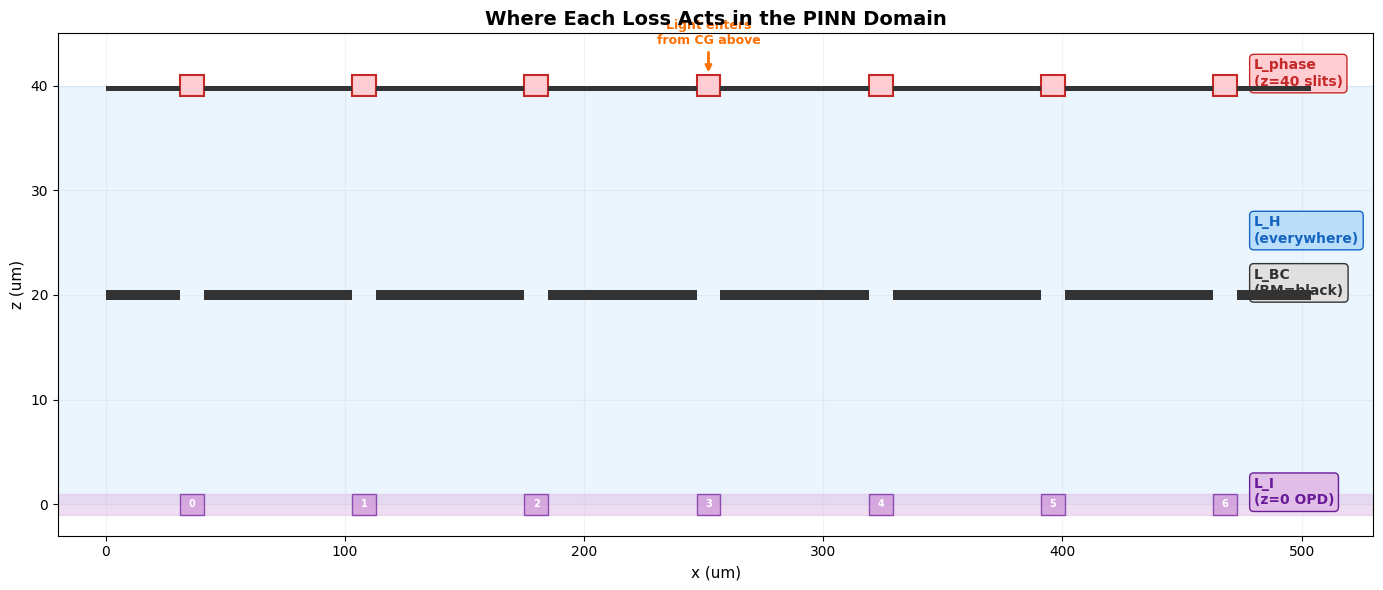

In [6]:
# ── 각 Loss가 PINN 도메인 어디에 적용되는지 시각화 ──

fig, ax = plt.subplots(figsize=(14, 6))

# Domain background
ax.set_xlim(-20, 530)
ax.set_ylim(-3, 45)
ax.set_xlabel('x (um)', fontsize=11)
ax.set_ylabel('z (um)', fontsize=11)
ax.set_title('Where Each Loss Acts in the PINN Domain', fontsize=14, fontweight='bold')

# L_H: everywhere (background)
ax.axhspan(0, 40, color='#BBDEFB', alpha=0.3)
ax.text(480, 25, 'L_H\n(everywhere)', fontsize=10, fontweight='bold', color='#1565C0',
        bbox=dict(boxstyle='round', facecolor='#BBDEFB', edgecolor='#1565C0'))

# L_phase: z=40 slit interiors
for i in range(7):
    cx = i * 72 + 36
    ax.add_patch(plt.Rectangle((cx-5, 39), 10, 2, facecolor='#FFCDD2', edgecolor='#C62828',
                               lw=1.5, zorder=3))
ax.text(480, 40, 'L_phase\n(z=40 slits)', fontsize=10, fontweight='bold', color='#C62828',
        bbox=dict(boxstyle='round', facecolor='#FFCDD2', edgecolor='#C62828'))

# L_BC: BM regions at z=20 and z=40
for i in range(7):
    cx = i * 72 + 36
    # BM1 at z=20 (left+right of slit)
    ax.add_patch(plt.Rectangle((i*72, 19.5), cx-5-i*72, 1, facecolor='#333', zorder=4))
    ax.add_patch(plt.Rectangle((cx+5, 19.5), (i+1)*72-cx-5, 1, facecolor='#333', zorder=4))
    # BM2 at z=40 (left+right of slit)
    ax.add_patch(plt.Rectangle((i*72, 39.5), cx-5-i*72, 0.5, facecolor='#333', zorder=4))
    ax.add_patch(plt.Rectangle((cx+5, 39.5), (i+1)*72-cx-5, 0.5, facecolor='#333', zorder=4))

ax.text(480, 20, 'L_BC\n(BM=black)', fontsize=10, fontweight='bold', color='#333',
        bbox=dict(boxstyle='round', facecolor='#E0E0E0', edgecolor='#333'))

# L_I: z=0 (OPD)
ax.axhspan(-1, 1, color='#E1BEE7', alpha=0.5, zorder=2)
for i in range(7):
    cx = i * 72 + 36
    ax.add_patch(plt.Rectangle((cx-5, -1), 10, 2, facecolor='#CE93D8',
                               edgecolor='#6A1B9A', lw=1, zorder=3, alpha=0.7))
    ax.text(cx, 0, str(i), ha='center', va='center', fontsize=7, color='white', fontweight='bold', zorder=5)
ax.text(480, 0, 'L_I\n(z=0 OPD)', fontsize=10, fontweight='bold', color='#6A1B9A',
        bbox=dict(boxstyle='round', facecolor='#E1BEE7', edgecolor='#6A1B9A'))

# Light direction
ax.annotate('Light enters\nfrom CG above', xy=(252, 41), xytext=(252, 44),
            ha='center', fontsize=9, color='#FF6F00', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#FF6F00', lw=2))

ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

---
# 6. Collocation Points

## 학습 데이터가 어디서 오는지

일반 AI는 **실제 데이터**(사진, 텍스트)가 필요합니다.

PINN은 **좌표만** 있으면 됩니다! 물리법칙이 "데이터" 역할을 하니까요.

"이 좌표(x,z)에서 물리법칙을 만족하나?" → PDE residual 계산 → loss

이 좌표들을 **collocation points**라고 부릅니다.

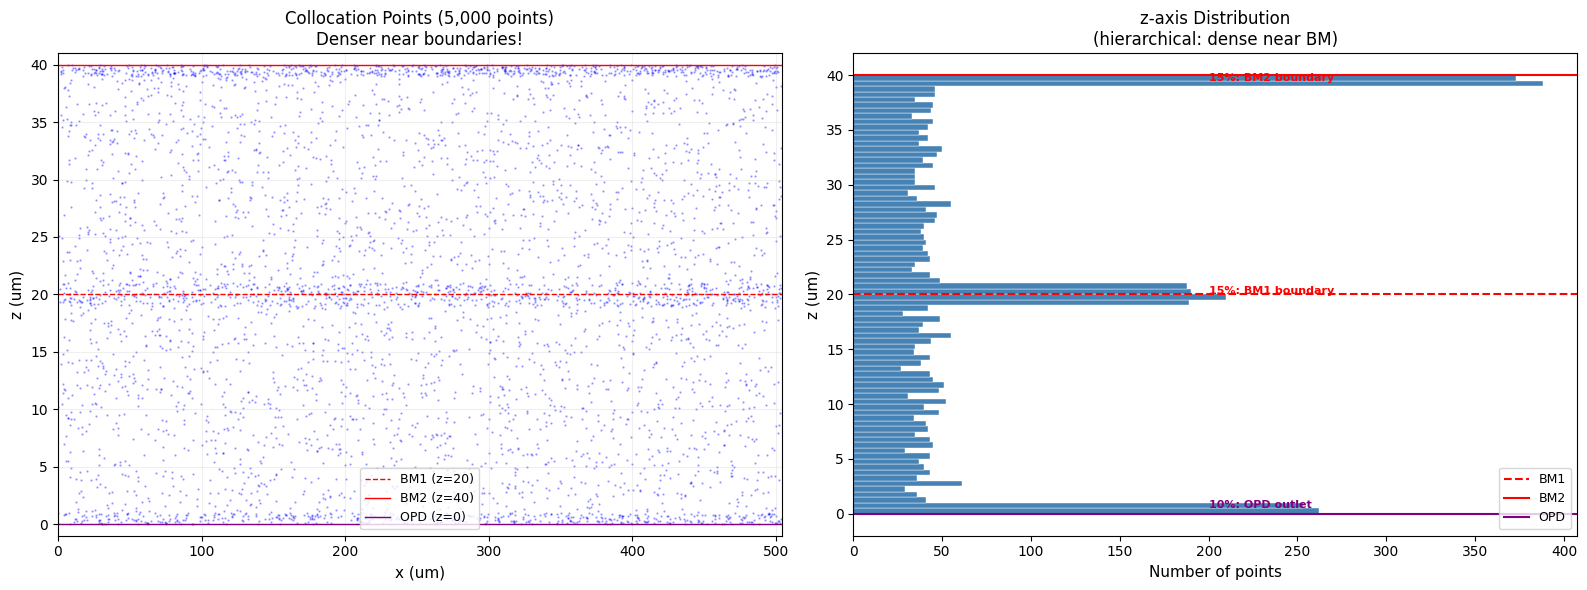

→ BM 경계(z=20, z=40) 근처에 점이 더 많이 모여 있음
→ 물리적으로 중요한 곳에 더 많은 학습 포인트 배치 = 효율적 학습
→ 매 epoch마다 5,000개의 새로운 점을 랜덤 생성


In [7]:
# ── Collocation point 분포 시각화 ──
from backend.training.collocation_sampler import hierarchical_collocation

points = hierarchical_collocation(5000, torch.device('cpu'))
x_pts = points[:, 0].numpy()
z_pts = points[:, 1].numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) 2D scatter
ax = axes[0]
ax.scatter(x_pts, z_pts, s=0.5, alpha=0.3, c='blue')
ax.axhline(y=20, color='red', ls='--', lw=1, label='BM1 (z=20)')
ax.axhline(y=40, color='red', ls='-', lw=1, label='BM2 (z=40)')
ax.axhline(y=0, color='purple', ls='-', lw=1, label='OPD (z=0)')
ax.set_xlabel('x (um)', fontsize=11)
ax.set_ylabel('z (um)', fontsize=11)
ax.set_title(f'Collocation Points ({len(x_pts):,} points)\nDenser near boundaries!', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 504)
ax.set_ylim(-1, 41)
ax.grid(True, alpha=0.2)

# (b) z-distribution histogram
ax = axes[1]
ax.hist(z_pts, bins=80, orientation='horizontal', color='steelblue', edgecolor='white', lw=0.3)
ax.axhline(y=20, color='red', ls='--', lw=1.5, label='BM1')
ax.axhline(y=40, color='red', ls='-', lw=1.5, label='BM2')
ax.axhline(y=0, color='purple', ls='-', lw=1.5, label='OPD')
ax.set_xlabel('Number of points', fontsize=11)
ax.set_ylabel('z (um)', fontsize=11)
ax.set_title('z-axis Distribution\n(hierarchical: dense near BM)', fontsize=12)
ax.legend(fontsize=9)

# Annotate dense regions
ax.annotate('15%: BM2 boundary', xy=(200, 39.5), fontsize=8, color='red', fontweight='bold')
ax.annotate('15%: BM1 boundary', xy=(200, 20), fontsize=8, color='red', fontweight='bold')
ax.annotate('10%: OPD outlet', xy=(200, 0.5), fontsize=8, color='purple', fontweight='bold')

plt.tight_layout()
plt.show()

print('→ BM 경계(z=20, z=40) 근처에 점이 더 많이 모여 있음')
print('→ 물리적으로 중요한 곳에 더 많은 학습 포인트 배치 = 효율적 학습')
print(f'→ 매 epoch마다 {len(x_pts):,}개의 새로운 점을 랜덤 생성')

---
# 7. Training Demo (Live!)

## 실제로 PINN이 학습하는 과정을 봅니다

- 작은 모델(CPU용)로 200 epoch 학습
- 학습 전/중/후의 **복소장 U(x,z)** 변화를 관찰
- Loss가 줄어들면서 물리적 패턴이 나타나는 과정을 확인

In [8]:
from backend.core.pinn_model import PurePINN
from backend.training.loss_functions import helmholtz_loss, phase_loss, bm_boundary_loss, ASMIncidentLUT
from backend.training.curriculum import CurriculumConfig, get_loss_weights, get_stage_name
from IPython.display import clear_output
import time

# Small model
model = PurePINN(hidden_dim=64, num_layers=3, num_freqs=24).to('cpu')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
asm_lut = ASMIncidentLUT(str(PROJECT_ROOT / 'data' / 'asm_luts' / 'incident_z40.npz'))
curriculum = CurriculumConfig(total_epochs=200, stage1_frac=0.20, stage2_frac=0.40)

# Visualization grid
N_VIS = 200
x_vis = torch.linspace(0, 504, N_VIS)
z_range = torch.linspace(0, 40, 50)
x_grid = torch.linspace(0, 504, 100)

def eval_field_map():
    Z, X = torch.meshgrid(z_range, x_grid, indexing='ij')
    N_m = Z.numel()
    with torch.no_grad():
        coords = torch.stack([X.flatten(), Z.flatten(),
                              torch.zeros(N_m), torch.zeros(N_m),
                              torch.full((N_m,), 10.0), torch.full((N_m,), 10.0),
                              torch.zeros(N_m), torch.ones(N_m)], dim=1)
        U = model(coords)
        return torch.sqrt(U[:,0]**2 + U[:,1]**2).reshape(50, 100).numpy()

# Train and visualize
history = {'total': [], 'L_H': [], 'L_phase': [], 'L_BC': []}
snapshots = {}

# Pre-training snapshot
model.eval()
snapshots[0] = eval_field_map()

t0 = time.time()
for epoch in range(200):
    model.train()
    w = get_loss_weights(epoch, curriculum)
    coords = hierarchical_collocation(1000, torch.device('cpu'))
    
    L_H = helmholtz_loss(model, coords) if w['lambda_H'] > 0 else torch.tensor(0.0)
    L_ph = phase_loss(model, asm_lut, 100, torch.device('cpu'))
    L_bc = bm_boundary_loss(model, 100, torch.device('cpu'))
    L_total = w['lambda_H']*L_H + w['lambda_phase']*L_ph + w['lambda_BC']*L_bc
    
    optimizer.zero_grad()
    L_total.backward()
    optimizer.step()
    
    history['total'].append(L_total.item())
    history['L_H'].append(L_H.item())
    history['L_phase'].append(L_ph.item())
    history['L_BC'].append(L_bc.item())
    
    if (epoch+1) in [40, 120, 200]:
        model.eval()
        snapshots[epoch+1] = eval_field_map()

elapsed = time.time() - t0
print(f'Training: 200 epochs in {elapsed:.1f}s')
print(f'Final loss: {history["total"][-1]:.4f}')

Training: 200 epochs in 4.5s
Final loss: 0.2152


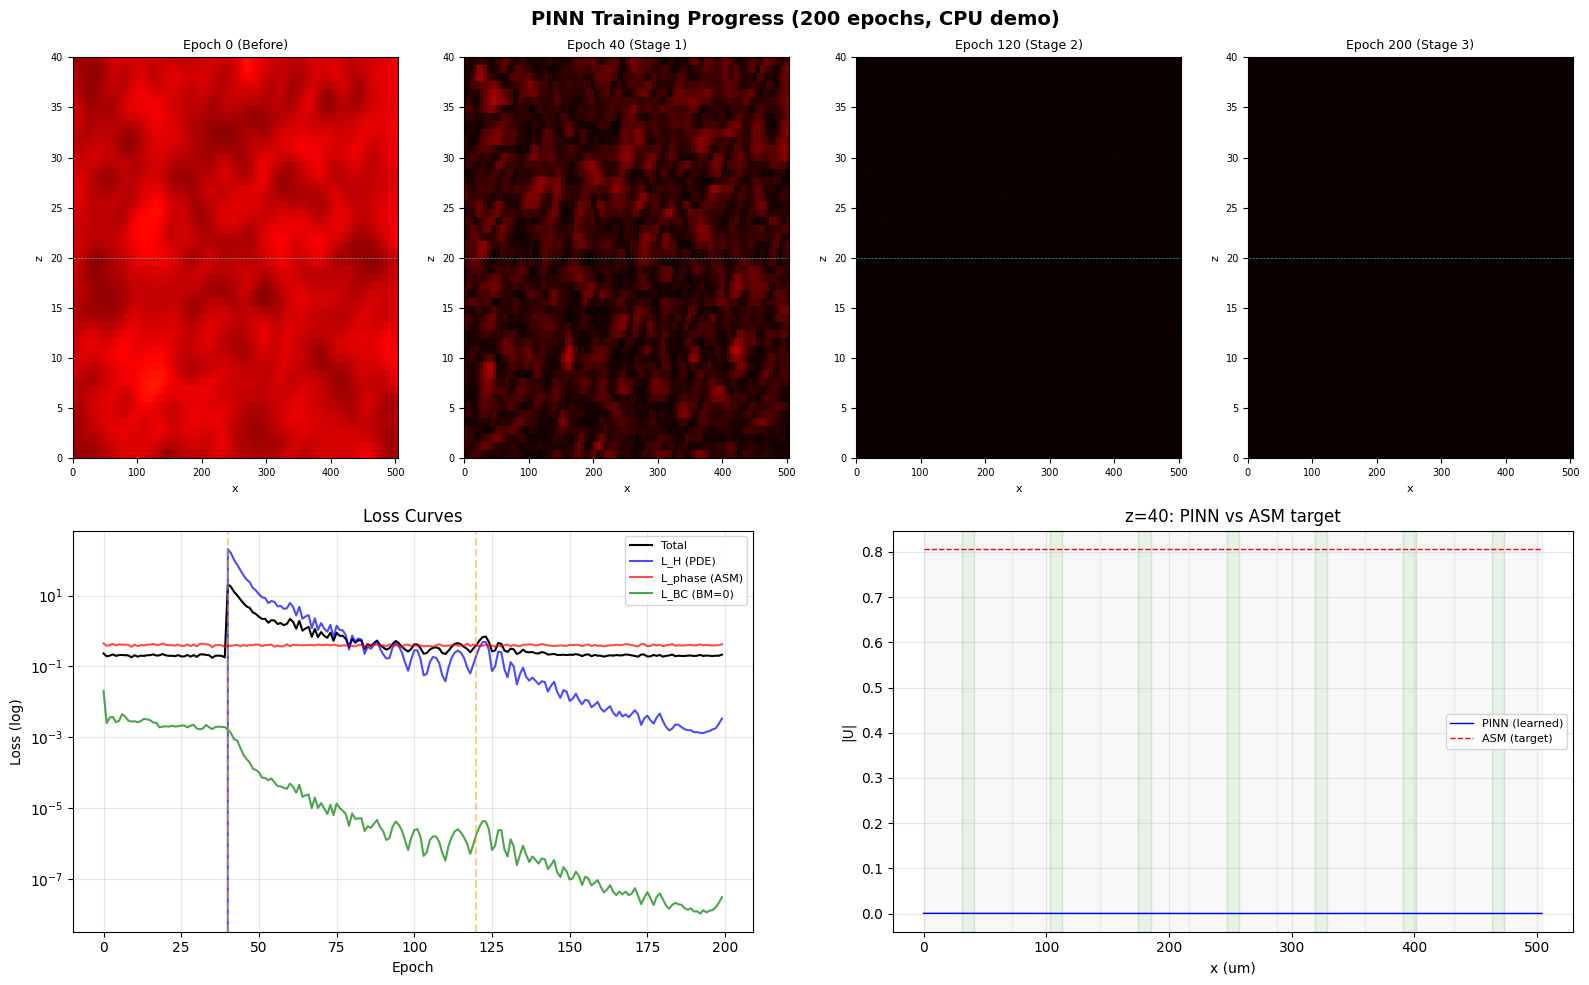


How to read this:
  - Top row: |U|(x,z) field maps evolve during training
  - Bottom left: all losses decreasing = good learning
  - Bottom right: blue (PINN) approaching red (ASM target) at z=40
  - Green bands = slit (light passes), gray = BM (U should be 0)


In [9]:
# ── Training Progress Visualization ──

fig = plt.figure(figsize=(16, 10))

# Top row: field maps at different epochs
snap_epochs = sorted(snapshots.keys())
for i, ep in enumerate(snap_epochs):
    ax = fig.add_subplot(2, 4, i+1)
    im = ax.imshow(snapshots[ep], aspect='auto', origin='lower',
                   extent=[0, 504, 0, 40], cmap='hot', vmin=0, vmax=0.5)
    ax.axhline(y=20, color='cyan', ls='--', lw=0.5, alpha=0.7)
    ax.axhline(y=40, color='cyan', ls='-', lw=0.5, alpha=0.7)
    stage = 'Before' if ep == 0 else get_stage_name(ep-1, curriculum).split(':')[0]
    ax.set_title(f'Epoch {ep} ({stage})', fontsize=9)
    ax.set_xlabel('x', fontsize=8)
    ax.set_ylabel('z', fontsize=8)
    ax.tick_params(labelsize=7)

# Loss curves
ax = fig.add_subplot(2, 2, 3)
ax.semilogy(history['total'], 'k-', lw=1.5, label='Total')
ax.semilogy(history['L_H'], 'b-', alpha=0.7, label='L_H (PDE)')
ax.semilogy(history['L_phase'], 'r-', alpha=0.7, label='L_phase (ASM)')
ax.semilogy(history['L_BC'], 'g-', alpha=0.7, label='L_BC (BM=0)')
ax.axvline(x=curriculum.stage1_end, color='orange', ls='--', alpha=0.5)
ax.axvline(x=curriculum.stage2_end, color='orange', ls='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log)')
ax.set_title('Loss Curves')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# z=40 cross-section: PINN vs ASM
ax = fig.add_subplot(2, 2, 4)
model.eval()
with torch.no_grad():
    coords_40 = torch.stack([x_vis, torch.full((N_VIS,), 40.0),
                             torch.zeros(N_VIS), torch.zeros(N_VIS),
                             torch.full((N_VIS,), 10.0), torch.full((N_VIS,), 10.0),
                             torch.zeros(N_VIS), torch.ones(N_VIS)], dim=1)
    U_40 = model(coords_40)
    amp_40 = torch.sqrt(U_40[:,0]**2 + U_40[:,1]**2).numpy()

U_asm_re, U_asm_im = asm_lut.lookup(x_vis, torch.zeros(N_VIS))
amp_asm = torch.sqrt(U_asm_re**2 + U_asm_im**2).numpy()

ax.plot(x_vis.numpy(), amp_40, 'b-', lw=1, label='PINN (learned)')
ax.plot(x_vis.numpy(), amp_asm, 'r--', lw=1, label='ASM (target)')
# Mark BM regions
for i in range(7):
    cx = i*72 + 36
    ax.axvspan(cx-5, cx+5, alpha=0.1, color='green')
    ax.axvspan(i*72, cx-5, alpha=0.05, color='gray')
    ax.axvspan(cx+5, (i+1)*72, alpha=0.05, color='gray')
ax.set_xlabel('x (um)')
ax.set_ylabel('|U|')
ax.set_title('z=40: PINN vs ASM target')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle('PINN Training Progress (200 epochs, CPU demo)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nHow to read this:')
print('  - Top row: |U|(x,z) field maps evolve during training')
print('  - Bottom left: all losses decreasing = good learning')
print('  - Bottom right: blue (PINN) approaching red (ASM target) at z=40')
print('  - Green bands = slit (light passes), gray = BM (U should be 0)')

---
# 8. How to Read Results

## 결과를 어떻게 해석하나

학습이 잘 되고 있는지 판단하는 기준:

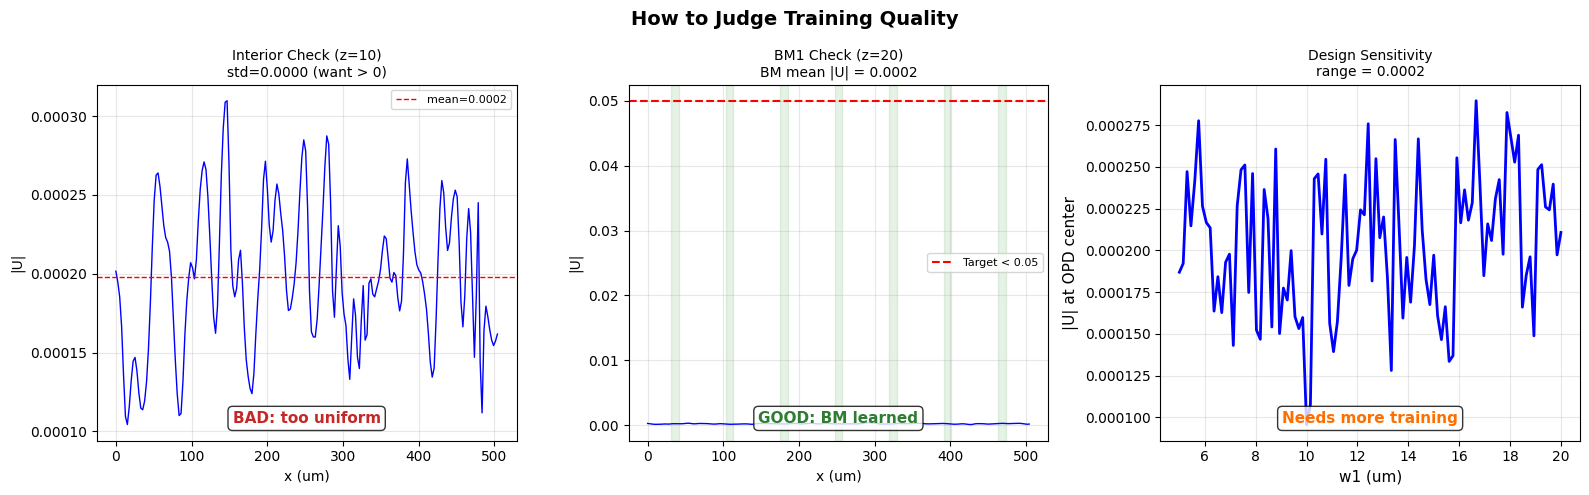


Red Flag Summary:

Interpretation guide:
  Interior uniform = BAD (plane wave, not learning diffraction)
  BM |U| > 0.05   = boundary not yet learned (need more epochs)
  No sensitivity   = not parametric yet (need more epochs)

Note: 200 epochs on CPU is very short.
Full training: 50K epochs on GPU → all checks should pass.


In [10]:
from backend.training.red_flag_detector import detect_red_flags

report = detect_red_flags(model, torch.device('cpu'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Check 1: Is the field uniform? (BAD = plane wave, no diffraction)
ax = axes[0]
with torch.no_grad():
    z10_coords = torch.stack([x_vis, torch.full((N_VIS,), 10.0),
                              torch.zeros(N_VIS), torch.zeros(N_VIS),
                              torch.full((N_VIS,), 10.0), torch.full((N_VIS,), 10.0),
                              torch.zeros(N_VIS), torch.ones(N_VIS)], dim=1)
    U_10 = model(z10_coords)
    amp_10 = torch.sqrt(U_10[:,0]**2 + U_10[:,1]**2).numpy()

ax.plot(x_vis.numpy(), amp_10, 'b-', lw=1)
ax.axhline(y=amp_10.mean(), color='red', ls='--', lw=1, label=f'mean={amp_10.mean():.4f}')
ax.set_title(f'Interior Check (z=10)\nstd={amp_10.std():.4f} (want > 0)', fontsize=10)
ax.set_xlabel('x (um)')
ax.set_ylabel('|U|')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

status = 'GOOD: variation' if amp_10.std() > 0.01 else 'BAD: too uniform'
color = '#2E7D32' if amp_10.std() > 0.01 else '#C62828'
ax.text(0.5, 0.05, status, transform=ax.transAxes, fontsize=11, fontweight='bold',
        ha='center', color=color, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Check 2: BM region |U| (should be near 0)
ax = axes[1]
with torch.no_grad():
    z20_coords = torch.stack([x_vis, torch.full((N_VIS,), 20.0),
                              torch.zeros(N_VIS), torch.zeros(N_VIS),
                              torch.full((N_VIS,), 10.0), torch.full((N_VIS,), 10.0),
                              torch.zeros(N_VIS), torch.ones(N_VIS)], dim=1)
    U_20 = model(z20_coords)
    amp_20 = torch.sqrt(U_20[:,0]**2 + U_20[:,1]**2).numpy()

ax.plot(x_vis.numpy(), amp_20, 'b-', lw=1)
for i in range(7):
    cx = i*72+36
    ax.axvspan(cx-5, cx+5, alpha=0.1, color='green')
ax.axhline(y=0.05, color='red', ls='--', label='Target < 0.05')
ax.set_title(f'BM1 Check (z=20)\nBM mean |U| = {report.bm1_mean_amp:.4f}', fontsize=10)
ax.set_xlabel('x (um)')
ax.set_ylabel('|U|')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

status = 'GOOD: BM learned' if report.bm1_mean_amp < 0.05 else 'Learning...'
color = '#2E7D32' if report.bm1_mean_amp < 0.05 else '#FF6F00'
ax.text(0.5, 0.05, status, transform=ax.transAxes, fontsize=11, fontweight='bold',
        ha='center', color=color, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Check 3: Design sensitivity
ax = axes[2]
w1_sweep = torch.linspace(5, 20, 100)
with torch.no_grad():
    coords_sw = torch.stack([torch.full((100,), 252.0), torch.zeros(100),
                             torch.zeros(100), torch.zeros(100),
                             w1_sweep, torch.full((100,), 10.0),
                             torch.zeros(100), torch.ones(100)], dim=1)
    U_sw = model(coords_sw)
    amp_sw = torch.sqrt(U_sw[:,0]**2 + U_sw[:,1]**2).numpy()

ax.plot(w1_sweep.numpy(), amp_sw, 'b-', lw=2)
ax.set_xlabel('w1 (um)', fontsize=11)
ax.set_ylabel('|U| at OPD center', fontsize=11)
ax.set_title(f'Design Sensitivity\nrange = {amp_sw.max()-amp_sw.min():.4f}', fontsize=10)
ax.grid(True, alpha=0.3)

status = 'GOOD: responds!' if amp_sw.max()-amp_sw.min() > 0.01 else 'Needs more training'
color = '#2E7D32' if amp_sw.max()-amp_sw.min() > 0.01 else '#FF6F00'
ax.text(0.5, 0.05, status, transform=ax.transAxes, fontsize=11, fontweight='bold',
        ha='center', color=color, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('How to Judge Training Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRed Flag Summary:')
print(report.summary())
print()
print('Interpretation guide:')
print('  Interior uniform = BAD (plane wave, not learning diffraction)')
print('  BM |U| > 0.05   = boundary not yet learned (need more epochs)')
print('  No sensitivity   = not parametric yet (need more epochs)')
print()
print('Note: 200 epochs on CPU is very short.')
print('Full training: 50K epochs on GPU → all checks should pass.')

---
## Summary

| Concept | One-line Summary |
|---------|------------------|
| Neural Network | input → adjustable function → output |
| PINN | NN + physics law = learn from equations |
| Parametric PINN | design vars as input → one model for ALL designs |
| Helmholtz | wave equation that light obeys (L_H) |
| L_phase | match ASM at boundary (input signal) |
| L_BC | BM blocks light = U=0 (ground condition) |
| Collocation | random coordinate points = "training data" |
| Inverse Design | BoTorch searches the design space using trained PINN |

### Why Parametric PINN enables Inverse Design:
```
1. PINN learns:  (delta, w, theta) → U(x,z) → PSF → MTF
2. BoTorch asks: "which (delta, w) gives best MTF?"
3. PINN answers:  instantly (0.8ms per query)
4. BoTorch finds: optimal design in ~8 seconds
5. vs LightTools: same search would take 833 hours
```